# Macro-Economic Risk Agent: everything in one notebook

Trains and compares, **on exactly the same rows and metrics**:
* **Ridge regression** and **gradient boosting** (classical models, a few minutes on CPU)
* **Two small LLMs fine-tuned with LoRA** (Qwen2.5-1.5B-Instruct and Phi-4-mini-instruct), each also scored **before** fine-tuning
* Two simple **baselines**: VIX alone, and each sector's average volatility

Task: from a **date-free macro snapshot + sector exposures**, forecast the sector ETF's realized volatility over the **next 60 trading days** and its LOW / MODERATE / HIGH label.
Splits: **train** 2006-2018, **val** 2019-2021 (tuning and epoch choice), **test** 2022-2024 and **post_cutoff** 2025-2026 (scored once, at the end).
Metrics: Spearman (pooled across sectors and within each sector), macro-F1 on the label, volatility error, JSON validity for the LLMs.

**How to run**
1. Runtime > Change runtime type > **GPU** (A100 if your plan allows). Then **Run all**.
2. Upload the three data files when asked: `eval_set.parquet`, `label_thresholds.json`, `sector_etf_close.parquet`.
3. Time on an A100: about 5 minutes for Ridge and gradient boosting, then about 25-35 minutes for the two LLMs. Results are saved to Google Drive (`MyDrive/macro_agent_results`) as each step finishes.
4. `SMOKE = True` makes the LLM part a 5-minute plumbing check. `RUN_LLM_FINETUNING = False` skips the LLMs (no GPU needed).
5. If a later cell complains about imports after the first cell changed packages, use **Runtime > Restart session** and run all again (uploaded files and downloaded models are kept).

In [ ]:
# torchao (preinstalled on Colab) can be too old for the current peft and breaks its import; we do not use it.
%pip uninstall -y -q torchao
%pip install -q "transformers>=4.48" "peft>=0.10" accelerate pyarrow scikit-learn matplotlib joblib

## 1. Settings

In [ ]:
MODELS = [
    "Qwen/Qwen2.5-1.5B-Instruct",       # 1.5B, Apache-2.0, no Hugging Face login needed
    "microsoft/Phi-4-mini-instruct",    # 3.8B, MIT, no Hugging Face login needed
]
RUN_LLM_FINETUNING = True    # False = only Ridge / gradient boosting / baselines (no GPU needed)
SMOKE = False                # False = real run (about 25-35 min on an A100); True = 5-minute plumbing check
EPOCHS = 2                   # small data (about 156 independent months): more epochs memorize
LEARNING_RATE = 2e-4
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
MAX_LEN = 1024               # prompt + answer tokens
RUN_ZERO_SHOT_BASELINE = True
SAVE_TO_DRIVE = True         # keeps adapters and results if Colab disconnects
SEED = 0

## 2. GPU check

In [ ]:
import subprocess
GPU, BF16, DTYPE = None, False, None
if RUN_LLM_FINETUNING:
    import torch
    from peft import LoraConfig            # fail fast here if peft cannot import (do not wait for the model download)
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout)
    assert torch.cuda.is_available(), "No GPU: Runtime > Change runtime type > GPU (or set RUN_LLM_FINETUNING = False)"
    GPU = torch.cuda.get_device_name(0)
    BF16 = torch.cuda.is_bf16_supported()
    DTYPE = torch.bfloat16 if BF16 else torch.float16
    print(f"GPU: {GPU} | training precision: {'bf16' if BF16 else 'fp16 + loss scaling'}")
    if "T4" in GPU and not SMOKE:
        print("T4 detected: the 3.8B model will take roughly 1-2 hours per epoch. "
              "Consider replacing it with a ~1.5B model in MODELS.")
else:
    print("RUN_LLM_FINETUNING = False: the LLM part is skipped.")

name, memory.total [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB

GPU: NVIDIA A100-SXM4-40GB | training precision: bf16


## 3. Data

In [ ]:
import json, math, os, random, re, time
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(os.environ.get("MACRO_DATA_DIR", "/content/macro_data"))
OUT_DIR = Path(os.environ.get("MACRO_OUT_DIR", "/content/macro_all_outputs"))
REQUIRED = ["eval_set.parquet", "label_thresholds.json", "sector_etf_close.parquet"]
DATA_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive, files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and SAVE_TO_DRIVE:
    drive.mount("/content/drive")
    OUT_DIR = Path("/content/drive/MyDrive/macro_agent_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
if missing and IN_COLAB:
    print("Select these files from your laptop:", missing)
    for name, content in files.upload().items():
        clean = re.sub(r" \(\d+\)(?=\.)", "", name)        # Colab renames repeats as 'x (1).parquet'
        (DATA_DIR / clean).write_bytes(content)
missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
assert not missing, f"Missing in {DATA_DIR}: {missing}"

ev = pd.read_parquet(DATA_DIR / "eval_set.parquet")
ev["as_of_date"] = pd.to_datetime(ev["as_of_date"])
thr = json.loads((DATA_DIR / "label_thresholds.json").read_text())
closes = pd.read_parquet(DATA_DIR / "sector_etf_close.parquet")
if "date" in closes.columns:
    closes = closes.set_index("date")
closes.index = pd.to_datetime(closes.index)
closes = closes.sort_index()

print(f"eval set: {len(ev):,} rows, {ev['etf'].nunique()} sectors, "
      f"{ev['as_of_date'].min().date()} -> {ev['as_of_date'].max().date()}")
print("label thresholds:", {k: round(v, 3) for k, v in thr.items() if isinstance(v, float)})
print(ev.groupby("split")["has_label"].agg(rows="size", labeled="sum"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Select these files from your laptop: ['sector_etf_close.parquet']


Saving sector_etf_close.parquet to sector_etf_close.parquet
eval set: 2,454 rows, 11 sectors, 2006-01-31 -> 2026-09-30
label thresholds: {'low_max': 0.13, 'moderate_max': 0.185}
             rows  labeled
split                     
post_cutoff   231      198
test          396      396
train        1434     1434
val           393      393


## 4. Features, target and splits
Two extra features computed from past data only: each sector's beta against SPY over the previous year, and its realized volatility over the previous 60 trading days (the latter is not a macro feature, so only one reference feature set uses it).

In [ ]:
rets = closes.pct_change(fill_method=None)
logret = np.log(closes.where(closes > 0)).diff()

def beta_and_trailing_vol(date, etf, window=252, vol_days=60):
    i = rets.index.searchsorted(pd.Timestamp(date), side="right") - 1
    if i < 1 or etf not in rets.columns:
        return np.nan, np.nan
    w = rets[[etf, "SPY"]].iloc[max(0, i - window):i].dropna()
    var = w["SPY"].var()
    beta = w[etf].cov(w["SPY"]) / var if len(w) >= 120 and var > 0 else np.nan
    lr = logret[etf].iloc[max(0, i - vol_days + 1):i + 1].dropna()
    vol = lr.std(ddof=1) * np.sqrt(252) if len(lr) >= 40 else np.nan
    return beta, vol

bv = [beta_and_trailing_vol(d, e) for d, e in zip(ev["as_of_date"], ev["etf"])]
ev["spy_beta"] = [b for b, _ in bv]
ev["trail_vol_60d"] = [v for _, v in bv]
print(ev[["spy_beta", "trail_vol_60d"]].describe().round(3))

       spy_beta  trail_vol_60d
count  2454.000       2454.000
mean      0.915          0.193
std       0.299          0.119
min      -0.302          0.057
25%       0.700          0.126
50%       0.963          0.161
75%       1.112          0.215
max       2.152          1.099


In [ ]:
NON_FEATURES = {"as_of_date", "etf", "sector", "split", "risk_label", "has_label", "n_obs", "r2",
                "fwd_vol_60d", "fwd_mdd_60d", "fwd_ret_60d", "beta_mkt", "trail_vol_60d", "spy_beta"}
macro_cols = [c for c in ev.columns
              if c not in NON_FEATURES and not c.startswith("beta_") and not c.startswith("BAMLH0A0HYM2")
              and pd.api.types.is_numeric_dtype(ev[c])]
sens_cols = [c for c in ["spy_beta", "beta_d_dgs10", "beta_r_oil", "beta_r_usd", "beta_d_vix", "beta_d_credit"]
             if c in ev.columns]
sector_dummies = pd.get_dummies(ev["etf"], prefix="sec", dtype=float)
ev = pd.concat([ev, sector_dummies], axis=1)
sector_cols = list(sector_dummies.columns)

FEATURE_SETS = {
    "sector only": sector_cols,
    "VIX only": ["VIXCLS"],
    "macro + sector": macro_cols + sens_cols + sector_cols,
    "macro + sector + recent vol": macro_cols + sens_cols + sector_cols + ["trail_vol_60d"],
}
for k, v in FEATURE_SETS.items():
    print(f"{k:30s} {len(v):3d} features")

lab = ev[ev["has_label"]].copy()
lab["y"] = np.log(lab["fwd_vol_60d"])          # log volatility: less skewed target

sector only                     11 features
VIX only                         1 features
macro + sector                  74 features
macro + sector + recent vol     75 features


### Prompts and targets for the LLMs
The prompt never contains a date or year. The target is what actually happened: realized volatility over the next 60 trading days, its LOW / MODERATE / HIGH label, and a 0-10 score (the volatility's percentile in the training years).

In [ ]:
FEATURES = ["DFF", "DFF_chg_3m", "DGS2", "DGS10", "DGS10_chg_3m", "DGS30", "T10Y2Y", "T10Y2Y_chg_3m", "T10Y3M",
            "MORTGAGE30US", "CPIAUCSL_yoy", "CPILFESL_yoy", "PCEPILFE_yoy", "PPIACO_yoy", "T5YIE", "UNRATE",
            "UNRATE_chg_3m", "PAYEMS_yoy", "ICSA_yoy", "GDPC1_yoy", "INDPRO_yoy", "RSAFS_yoy", "HOUST_yoy",
            "UMCSENT", "CFNAI", "VIXCLS", "VIXCLS_chg_3m", "BAA10Y", "BAA10Y_chg_3m", "NFCI", "STLFSI4",
            "DCOILWTICO", "DCOILWTICO_ret_3m", "DTWEXBGS_ret_3m", "VIXCLS_z3y", "BAA10Y_z3y", "T10Y2Y_z3y",
            "CPIAUCSL_yoy_z3y"]
SENS = [("sector_beta_sp500", "spy_beta", 1.0), ("sens_10y_yield_per_10bp", "beta_d_dgs10", 10.0),
        ("sens_oil_per_10pct", "beta_r_oil", 10.0), ("sens_usd_per_1pct", "beta_r_usd", 1.0),
        ("sens_vix_per_1pt", "beta_d_vix", 100.0), ("sens_credit_per_10bp", "beta_d_credit", 10.0)]
LO, HI = thr["low_max"] * 100, thr["moderate_max"] * 100
HEADER = (
    "You are the Macro-Economic Risk Agent. Using only the numbers below (no dates are given), forecast this "
    "sector ETF's annualized realized volatility over the next 60 trading days.\n"
    f"Labels: LOW below {LO:.1f}%, MODERATE {LO:.1f}% to {HI:.1f}%, HIGH above {HI:.1f}%. "
    "macro_risk_score: 0 (calm) to 10 (turbulent).\n"
    'Reply with JSON only: {"expected_vol_pct": <number>, "risk_label": "LOW|MODERATE|HIGH", "macro_risk_score": <number>}'
)

def build_prompt(r) -> str:
    lines = [HEADER, "", f"SECTOR: {r['sector']}", "SECTOR SENSITIVITIES (% sector return per move, net of market):"]
    for key, col, scale in SENS:
        if col in r.index and pd.notna(r[col]):
            lines.append(f"{key}: {round(float(r[col]) * scale, 3)}")
    lines.append("INDICATORS:")
    for c in FEATURES:
        if c in r.index and pd.notna(r[c]):
            lines.append(f"{c}: {round(float(r[c]), 3)}")
    return "\n".join(lines)

train_vols = np.sort(lab.loc[lab["split"] == "train", "fwd_vol_60d"].to_numpy())
def vol_to_score(v: float) -> float:
    return round(10 * np.searchsorted(train_vols, v, side="right") / len(train_vols), 1)

def build_target(r) -> str:
    return json.dumps({"expected_vol_pct": round(float(r["fwd_vol_60d"]) * 100, 1),
                       "risk_label": r["risk_label"], "macro_risk_score": vol_to_score(r["fwd_vol_60d"])})

lab["prompt"] = [build_prompt(r) for _, r in lab.iterrows()]
lab["target"] = [build_target(r) for _, r in lab.iterrows()]
lab["prompt_id"] = [f"{d:%Y%m%d}_{e}" for d, e in zip(lab["as_of_date"], lab["etf"])]
assert not lab["prompt"].str.contains(r"\b(?:19|20)\d\d-\d\d|as_of", case=False).any(), "a prompt leaks a date"

train_df = lab[lab["split"] == "train"].reset_index(drop=True)
val_df = lab[lab["split"] == "val"].reset_index(drop=True)
eval_df = lab[lab["split"].isin(["test", "post_cutoff"])].reset_index(drop=True)

# the 27 month-ends scored by compare_macro_models.py (same selection rule)
dates = sorted(eval_df["as_of_date"].unique())
if len(dates) > 27:
    dates = [dates[i] for i in np.unique(np.linspace(0, len(dates) - 1, 27).round().astype(int))]
eval_df["in_llm_comparison"] = eval_df["as_of_date"].isin(dates)

if SMOKE:
    train_df = train_df.sample(48, random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(16, random_state=SEED).reset_index(drop=True)
    eval_df = pd.concat([g.sample(min(12, len(g)), random_state=SEED)
                         for _, g in eval_df.groupby("split")]).reset_index(drop=True)
print(f"train {len(train_df)} | val {len(val_df)} | eval {len(eval_df)} (test + post_cutoff){'  [SMOKE]' if SMOKE else ''}")
print("\nExample prompt:\n" + train_df["prompt"].iloc[0][:900] + "\n...\nExample target: " + train_df["target"].iloc[0])

parts = {s: lab[lab["split"] == s] for s in ["train", "val", "test", "post_cutoff"]}
print("\nNote: all 11 sectors share the same macro snapshot each month, so the train split has only "
      f"{parts['train']['as_of_date'].nunique()} independent months. Models are kept strongly regularized.")

train 1434 | val 393 | eval 594 (test + post_cutoff)

Example prompt:
You are the Macro-Economic Risk Agent. Using only the numbers below (no dates are given), forecast this sector ETF's annualized realized volatility over the next 60 trading days.
Labels: LOW below 13.0%, MODERATE 13.0% to 18.5%, HIGH above 18.5%. macro_risk_score: 0 (calm) to 10 (turbulent).
Reply with JSON only: {"expected_vol_pct": <number>, "risk_label": "LOW|MODERATE|HIGH", "macro_risk_score": <number>}

SECTOR: Materials
SECTOR SENSITIVITIES (% sector return per move, net of market):
sector_beta_sp500: 1.209
sens_10y_yield_per_10bp: 0.178
sens_oil_per_10pct: 0.161
sens_vix_per_1pt: -0.133
sens_credit_per_10bp: -0.216
INDICATORS:
DFF: 4.48
DFF_chg_3m: 0.47
DGS2: 4.52
DGS10: 4.54
DGS10_chg_3m: -0.06
DGS30: 4.67
T10Y2Y: 0.02
T10Y2Y_chg_3m: -0.2
T10Y3M: 0.06
MORTGAGE30US: 6.1
CPIAUCSL_yoy: 3.454
CPILFESL_yoy: 2.166
PCEPILFE_yoy: 2.766
PPIACO_yoy: 8.594
T5YIE: 2.54
UNRATE: 4.9
UNRATE_chg
...
Example target: {"expecte

## 5. Metrics (one definition for every model)

In [ ]:
LABELS = ["LOW", "MODERATE", "HIGH"]

def spearman(a, b):
    m = pd.DataFrame({"a": a, "b": b}).dropna()
    if len(m) < 8 or m["a"].nunique() < 2 or m["b"].nunique() < 2:
        return np.nan
    return float(m["a"].rank().corr(m["b"].rank()))

def within_sector(df, pred):
    vals = [spearman(g[pred], g["fwd_vol_60d"]) for _, g in df.groupby("etf") if len(g) >= 8]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else np.nan

def to_label(v):
    return "LOW" if v <= thr["low_max"] else "MODERATE" if v <= thr["moderate_max"] else "HIGH"

def macro_f1(y_true, y_pred):
    f1s = []
    for c in LABELS:
        tp = sum((t == c) and (p == c) for t, p in zip(y_true, y_pred))
        fp = sum((t != c) and (p == c) for t, p in zip(y_true, y_pred))
        fn = sum((t == c) and (p != c) for t, p in zip(y_true, y_pred))
        if tp + fn == 0:
            continue
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn)
        f1s.append(0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec))
    return float(np.mean(f1s)) if f1s else np.nan

def evaluate(df, pred_vol):
    d = df.assign(pred=pred_vol)
    return {
        "spearman_pooled": spearman(d["pred"], d["fwd_vol_60d"]),
        "spearman_within_sector": within_sector(d, "pred"),
        "macro_f1": macro_f1(d["risk_label"].tolist(), [to_label(v) for v in d["pred"]]),
        "vol_mae_pp": float((d["pred"] - d["fwd_vol_60d"]).abs().mean() * 100),
        "n": len(d),
    }

def val_score(m):     # selection metric: average of pooled and within-sector Spearman
    return np.nanmean([m["spearman_pooled"], m["spearman_within_sector"]])

In [ ]:
# Parsing the LLMs' JSON answers and scoring them with the same metrics
def extract_json(text):
    if not text:
        return None
    t = re.sub(r"<think>.*?</think>", "", text, flags=re.S).strip()
    try:
        return json.loads(t)
    except Exception:
        pass
    start, depth = None, 0
    for i, ch in enumerate(t):
        if ch == "{":
            start = i if depth == 0 else start
            depth += 1
        elif ch == "}" and depth:
            depth -= 1
            if depth == 0 and start is not None:
                try:
                    return json.loads(t[start:i + 1])
                except Exception:
                    start = None
    return None

def is_num(x):
    return isinstance(x, (int, float)) and not isinstance(x, bool) and math.isfinite(x)

def parse_answer(text):
    o = extract_json(text)
    if not isinstance(o, dict):
        return None
    lab_ = str(o.get("risk_label", "")).upper().strip()
    if not (is_num(o.get("expected_vol_pct")) and is_num(o.get("macro_risk_score")) and lab_ in LABELS):
        return None
    return {"exp_vol_pct": float(o["expected_vol_pct"]), "label": lab_,
            "score": float(min(10, max(0, o["macro_risk_score"])))}

def score_outputs(df, texts):
    parsed = [parse_answer(t) for t in texts]
    d = df.copy()
    d["raw_output"] = texts
    d["valid"] = [p is not None for p in parsed]
    for k in ("exp_vol_pct", "label", "score"):
        d[k] = [p[k] if p else None for p in parsed]
    d["exp_vol_pct"] = pd.to_numeric(d["exp_vol_pct"])
    d["score"] = pd.to_numeric(d["score"])
    v = d[d["valid"]]
    m = {"n": len(d), "valid_rate": float(d["valid"].mean()),
         "spearman_pooled": spearman(v["exp_vol_pct"], v["fwd_vol_60d"]) if len(v) else np.nan,
         "spearman_within_sector": within_sector(v, "exp_vol_pct") if len(v) else np.nan,
         "spearman_score": spearman(v["score"], v["fwd_vol_60d"]) if len(v) else np.nan,
         "macro_f1": macro_f1(d["risk_label"].tolist(), d["label"].tolist()),
         "vol_mae_pp": float((v["exp_vol_pct"] - v["fwd_vol_60d"] * 100).abs().mean()) if len(v) else np.nan}
    return d, m

## 6. Ridge and gradient boosting: train on 2006-2018, tune on 2019-2021

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def make_model(kind, params):
    if kind == "ridge":
        return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=params["alpha"]))
    return HistGradientBoostingRegressor(random_state=0, **params)     # handles missing values natively

GRIDS = {
    "ridge": [{"alpha": a} for a in (1, 10, 100, 1000)],
    "gbm": [{"max_depth": d, "learning_rate": lr, "max_iter": it, "min_samples_leaf": 40, "l2_regularization": 1.0}
            for d in (2, 3) for lr in (0.03, 0.06) for it in (150, 300)],
}
PLAN = [("sector only", "ridge"), ("VIX only", "ridge"),
        ("macro + sector", "ridge"), ("macro + sector", "gbm"),
        ("macro + sector + recent vol", "ridge"), ("macro + sector + recent vol", "gbm")]

tuning, best = [], {}
tr, va = parts["train"], parts["val"]
for fs, kind in PLAN:
    cols = FEATURE_SETS[fs]
    for params in GRIDS[kind]:
        m = make_model(kind, params).fit(tr[cols], tr["y"])
        met = evaluate(va, np.exp(m.predict(va[cols])))
        tuning.append({"features": fs, "model": kind, "params": json.dumps(params), "val_score": val_score(met), **met})
        if (fs, kind) not in best or val_score(met) > best[(fs, kind)]["val_score"]:
            best[(fs, kind)] = {"params": params, "val_score": val_score(met), "train_only_model": m}
tuning = pd.DataFrame(tuning)
tuning.to_csv(OUT_DIR / "tuning_results.csv", index=False)
print("Best settings on the validation split:")
for (fs, kind), b in best.items():
    print(f"  {fs:30s} {kind:6s} val score {b['val_score']:.3f}  {b['params']}")

Best settings on the validation split:
  sector only                    ridge  val score 0.456  {'alpha': 1}
  VIX only                       ridge  val score 0.396  {'alpha': 1}
  macro + sector                 ridge  val score 0.338  {'alpha': 10}
  macro + sector                 gbm    val score 0.434  {'max_depth': 2, 'learning_rate': 0.06, 'max_iter': 150, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
  macro + sector + recent vol    ridge  val score 0.310  {'alpha': 10}
  macro + sector + recent vol    gbm    val score 0.314  {'max_depth': 2, 'learning_rate': 0.03, 'max_iter': 150, 'min_samples_leaf': 40, 'l2_regularization': 1.0}


### Final models: refit on train + val, evaluate once on test and post_cutoff
Train and val rows below come from the train-only fit (so val is honest); test and post_cutoff come from the refit on train + val.

In [ ]:
results, final_models, preds = [], {}, []
trva = pd.concat([tr, va])
for (fs, kind), b in best.items():
    cols = FEATURE_SETS[fs]
    m_tr = b["train_only_model"]
    m_final = make_model(kind, b["params"]).fit(trva[cols], trva["y"])
    final_models[(fs, kind)] = m_final
    for split, d, model in [("train", tr, m_tr), ("val", va, m_tr),
                            ("test", parts["test"], m_final), ("post_cutoff", parts["post_cutoff"], m_final)]:
        p = np.exp(model.predict(d[cols]))
        results.append({"features": fs, "model": kind, "split": split, **evaluate(d, p)})
        if split in ("test", "post_cutoff"):
            preds.append(d[["as_of_date", "etf", "split", "risk_label", "fwd_vol_60d"]].assign(
                features=fs, model=kind, pred_vol=p, pred_label=[to_label(v) for v in p]))
results = pd.DataFrame(results)
preds = pd.concat(preds, ignore_index=True)
results.to_csv(OUT_DIR / "results_by_split.csv", index=False)
preds.to_csv(OUT_DIR / "test_predictions.csv", index=False)

view = results.pivot_table(index=["features", "model"], columns="split",
                           values=["spearman_pooled", "spearman_within_sector", "macro_f1"])
view = view.reindex(columns=["train", "val", "test", "post_cutoff"], level=1).round(3)
pd.set_option("display.width", 220)
view

macro_f1                           spearman_pooled                           spearman_within_sector                          
split                                train    val   test post_cutoff           train    val   test post_cutoff                  train    val   test post_cutoff
features                    model                                                                                                                              
VIX only                    ridge    0.427  0.391  0.400       0.250           0.491  0.341  0.595       0.175                  0.532  0.451  0.723       0.222
macro + sector              gbm      0.772  0.501  0.574       0.438           0.918  0.522  0.759       0.262                  0.887  0.345  0.628      -0.061
                            ridge    0.687  0.396  0.451       0.471           0.835  0.337  0.739       0.228                  0.743  0.339  0.675       0.046
macro + sector + recent vol gbm      0.725  0.504  0.620       0.433           0.870  0.407  0.785       0.184                  0.822  0.221  0.676      -0.175
                            ridge    0.698  0.375  0.453       0.451           0.840  0.318  0.755       0.186                  0.751  0.301  0.683      -0.046
sector only                 ridge    0.454  0.464  0.451       0.405           0.422  0.456  0.341       0.248                    NaN    NaN    NaN      -0.117

### The classical macro-agent model
Chosen by **validation score only** among the pure-macro feature set (`macro + sector`). The `+ recent vol` rows are a reference: recent volatility belongs to the volatility agent, not the macro agent.

In [ ]:
cands = {k: v for k, v in best.items() if k[0] == "macro + sector"}
AGENT_KEY = max(cands, key=lambda k: cands[k]["val_score"])
print("Macro agent model:", AGENT_KEY, best[AGENT_KEY]["params"])
summary = results[(results["features"] == AGENT_KEY[0]) & (results["model"] == AGENT_KEY[1])].set_index("split")
print(summary[["n", "spearman_pooled", "spearman_within_sector", "macro_f1", "vol_mae_pp"]].round(3))
print("\nBaselines on test:")
print(results[(results["split"] == "test") & results["features"].isin(["sector only", "VIX only"])]
      [["features", "spearman_pooled", "spearman_within_sector", "macro_f1"]].round(3).to_string(index=False))

Macro agent model: ('macro + sector', 'gbm') {'max_depth': 2, 'learning_rate': 0.06, 'max_iter': 150, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
                n  spearman_pooled  spearman_within_sector  macro_f1  vol_mae_pp
split                                                                           
train        1434            0.918                   0.887     0.772       2.489
val           393            0.522                   0.345     0.501       7.596
test          396            0.759                   0.628     0.574       3.917
post_cutoff   198            0.262                  -0.061     0.438       4.696

Baselines on test:
   features  spearman_pooled  spearman_within_sector  macro_f1
sector only            0.341                     NaN     0.451
   VIX only            0.595                   0.723     0.400


### Same rows as the LLM comparison script (`compare_macro_models.py`)

In [ ]:
tp = pd.concat([parts["test"], parts["post_cutoff"]])
dates = sorted(tp["as_of_date"].unique())
if len(dates) > 27:
    idx = np.unique(np.linspace(0, len(dates) - 1, 27).round().astype(int))
    dates = [dates[i] for i in idx]
llm_rows = tp[tp["as_of_date"].isin(dates)]
same = []
for (fs, kind), m in final_models.items():
    p = np.exp(m.predict(llm_rows[FEATURE_SETS[fs]]))
    same.append({"features": fs, "model": kind, **evaluate(llm_rows, p)})
same = pd.DataFrame(same)
same.to_csv(OUT_DIR / "same_rows_as_llm_comparison.csv", index=False)
same.round(3)

,features,model,spearman_pooled,spearman_within_sector,macro_f1,vol_mae_pp,n
0,sector only,ridge,0.315,NaN,0.445,4.956,297
1,VIX only,ridge,0.502,0.591,0.328,4.463,297
2,macro + sector,ridge,0.609,0.567,0.493,5.174,297
3,macro + sector,gbm,0.597,0.453,0.574,3.932,297
4,macro + sector + recent vol,ridge,0.603,0.552,0.482,5.189,297
5,macro + sector + recent vol,gbm,0.599,0.425,0.579,3.782,297


### Plots for the classical models

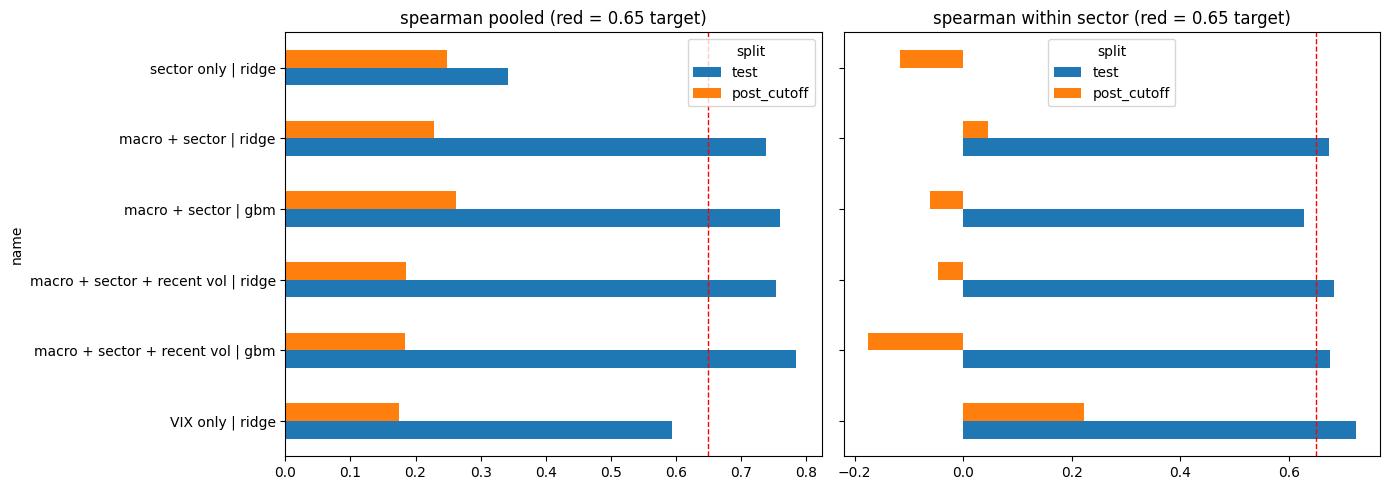

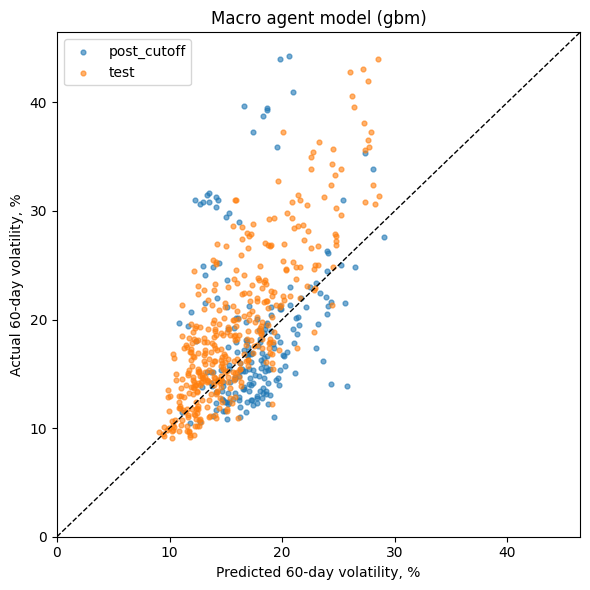

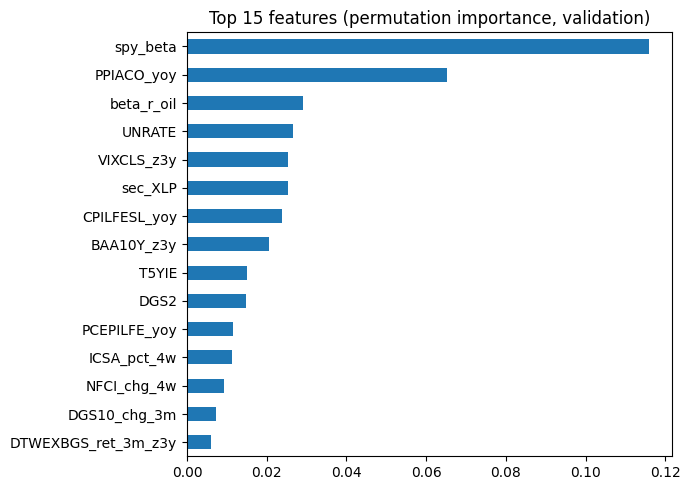

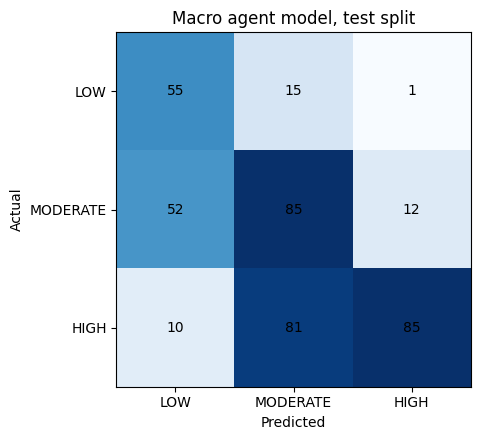

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# (a) Spearman by model on test and post_cutoff
t = results[results["split"].isin(["test", "post_cutoff"])].copy()
t["name"] = t["features"] + " | " + t["model"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric in zip(axes, ["spearman_pooled", "spearman_within_sector"]):
    pv = t.pivot_table(index="name", columns="split", values=metric).reindex(columns=["test", "post_cutoff"])
    pv.plot.barh(ax=ax)
    ax.axvline(0.65, color="red", ls="--", lw=1)
    ax.set_title(metric.replace("_", " ") + " (red = 0.65 target)")
fig.tight_layout(); fig.savefig(OUT_DIR / "plot_spearman_by_model.png", dpi=160); plt.show()

# (b) predicted vs actual, macro agent model, test + post_cutoff
pa = preds[(preds["features"] == AGENT_KEY[0]) & (preds["model"] == AGENT_KEY[1])]
fig, ax = plt.subplots(figsize=(6, 6))
for s, g in pa.groupby("split"):
    ax.scatter(g["pred_vol"] * 100, g["fwd_vol_60d"] * 100, s=12, alpha=0.6, label=s)
lim = [0, max(pa["pred_vol"].max(), pa["fwd_vol_60d"].max()) * 105]
ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Predicted 60-day volatility, %"); ax.set_ylabel("Actual 60-day volatility, %")
ax.set_title(f"Macro agent model ({AGENT_KEY[1]})"); ax.legend()
fig.tight_layout(); fig.savefig(OUT_DIR / "plot_pred_vs_actual.png", dpi=160); plt.show()

# (c) what the model relies on: permutation importance on the validation split
m_tr = best[AGENT_KEY]["train_only_model"]
cols = FEATURE_SETS[AGENT_KEY[0]]
pi = permutation_importance(m_tr, va[cols], va["y"], n_repeats=10, random_state=0)
imp = pd.Series(pi.importances_mean, index=cols).sort_values(ascending=False).head(15)
imp.to_csv(OUT_DIR / "feature_importance_top15.csv")
fig, ax = plt.subplots(figsize=(7, 5))
imp[::-1].plot.barh(ax=ax); ax.set_title("Top 15 features (permutation importance, validation)")
fig.tight_layout(); fig.savefig(OUT_DIR / "plot_feature_importance.png", dpi=160); plt.show()

# (d) confusion matrix on test
pt = pa[pa["split"] == "test"]
cm = pd.crosstab(pd.Categorical(pt["risk_label"], LABELS), pd.Categorical(pt["pred_label"], LABELS),
                 rownames=["actual"], colnames=["predicted"], dropna=False)
fig, ax = plt.subplots(figsize=(5, 4.5)); ax.imshow(cm.values, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm.values[i, j], ha="center", va="center")
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS); ax.set_yticks(range(3)); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Macro agent model, test split")
fig.tight_layout(); fig.savefig(OUT_DIR / "plot_confusion_matrix_test.png", dpi=160); plt.show()

## 7. LoRA fine-tuning of the two small LLMs
Each model is scored **before** fine-tuning (zero-shot), trained on the train split, the epoch with the lowest validation loss is kept, and it is scored again. Adapters are saved to Drive after each model.

In [ ]:
import torch
import gc
from importlib.metadata import version as pkg_version
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict

def dtype_kwargs():
    major, minor = (int(x) for x in pkg_version("transformers").split(".")[:2])
    return {"dtype": DTYPE} if (major, minor) >= (4, 56) else {"torch_dtype": DTYPE}

def load(name):
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(name, low_cpu_mem_usage=True, **dtype_kwargs()).to("cuda")
    return tok, model

def chat_parts(tok):
    """Text placed before an answer, and the end-of-turn text after it, for this model's chat template."""
    marker = "QQMARKERQQ"
    full = tok.apply_chat_template([{"role": "user", "content": "x"}, {"role": "assistant", "content": marker}],
                                   tokenize=False)
    suffix = full.split(marker, 1)[1] if marker in full else (tok.eos_token or "")
    return suffix

def prompt_text(tok, user):
    return tok.apply_chat_template([{"role": "user", "content": user}], tokenize=False, add_generation_prompt=True)

def stop_ids(tok, model, suffix):
    ids = set()
    for x in (tok.eos_token_id, getattr(model.generation_config, "eos_token_id", None)):
        if isinstance(x, int):
            ids.add(x)
        elif isinstance(x, (list, tuple)):
            ids.update(i for i in x if isinstance(i, int))
    first = suffix.strip().split("\n")[0]
    if first:
        i = tok.convert_tokens_to_ids(first)
        if isinstance(i, int) and i != tok.unk_token_id:
            ids.add(i)
    return sorted(ids)

def encode(tok, user, answer, suffix):
    p = tok(prompt_text(tok, user), add_special_tokens=False)["input_ids"]
    a = tok(answer + suffix, add_special_tokens=False)["input_ids"]
    p = p[-(MAX_LEN - len(a)):] if len(p) + len(a) > MAX_LEN else p     # keep the answer, trim the prompt start
    return {"input_ids": p + a, "labels": [-100] * len(p) + a}

def collate(batch, pad_id):
    n = max(len(b["input_ids"]) for b in batch)
    ids = torch.full((len(batch), n), pad_id, dtype=torch.long)
    labels = torch.full((len(batch), n), -100, dtype=torch.long)
    mask = torch.zeros((len(batch), n), dtype=torch.long)
    for i, b in enumerate(batch):
        L = len(b["input_ids"])
        ids[i, :L] = torch.tensor(b["input_ids"])
        labels[i, :L] = torch.tensor(b["labels"])
        mask[i, :L] = 1
    return {"input_ids": ids, "labels": labels, "attention_mask": mask}

@torch.no_grad()
def generate(tok, model, prompts, batch_size, max_new_tokens, suffix):
    model.eval()
    model.config.use_cache = True
    tok.padding_side = "left"
    eos = stop_ids(tok, model, suffix)
    outs, secs = [], []
    for i in range(0, len(prompts), batch_size):
        texts = [prompt_text(tok, p) for p in prompts[i:i + batch_size]]
        enc = tok(texts, return_tensors="pt", padding=True, add_special_tokens=False).to("cuda")
        t0 = time.time()
        gen = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False, eos_token_id=eos,
                             pad_token_id=tok.pad_token_id)
        secs.append((time.time() - t0) / len(texts))
        outs += tok.batch_decode(gen[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    tok.padding_side = "right"
    return outs, float(np.mean(secs))

@torch.no_grad()
def val_loss(model, loader):
    model.eval()
    tot, n = 0.0, 0
    for b in loader:
        b = {k: v.to("cuda") for k, v in b.items()}
        with torch.autocast("cuda", dtype=DTYPE):
            tot += model(**b).loss.item()
        n += 1
    return tot / max(n, 1)

def finetune(name, tok, model, suffix, log):
    big = sum(p.numel() for p in model.parameters()) > 2.5e9
    micro, accum = (2, 8) if big else (4, 4)
    model.config.use_cache = False
    try:
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        model.enable_input_require_grads()
    except Exception as e:
        print("gradient checkpointing not enabled:", e)
    cfg = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
                     target_modules="all-linear", task_type="CAUSAL_LM")
    model = get_peft_model(model, cfg)
    model.print_trainable_parameters()

    tr = [encode(tok, p, a, suffix) for p, a in zip(train_df["prompt"], train_df["target"])]
    va = [encode(tok, p, a, suffix) for p, a in zip(val_df["prompt"], val_df["target"])]
    print(f"tokens per example: mean {np.mean([len(x['input_ids']) for x in tr]):.0f}, "
          f"max {max(len(x['input_ids']) for x in tr)}")
    g = torch.Generator().manual_seed(SEED)
    tl = DataLoader(tr, batch_size=micro, shuffle=True, generator=g, collate_fn=lambda b: collate(b, tok.pad_token_id))
    vl = DataLoader(va, batch_size=micro, shuffle=False, collate_fn=lambda b: collate(b, tok.pad_token_id))

    epochs = 1 if SMOKE else EPOCHS
    steps_per_epoch = math.ceil(len(tl) / accum)
    total = 6 if SMOKE else steps_per_epoch * epochs
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=0.0)
    sched = get_cosine_schedule_with_warmup(opt, max(1, int(0.05 * total)), total)
    scaler = torch.amp.GradScaler("cuda", enabled=(DTYPE == torch.float16))

    best, best_state, step, t0 = float("inf"), None, 0, time.time()
    for ep in range(epochs):
        model.train()
        run_loss = 0.0
        for i, b in enumerate(tl):
            b = {k: v.to("cuda") for k, v in b.items()}
            with torch.autocast("cuda", dtype=DTYPE):
                loss = model(**b).loss / accum
            scaler.scale(loss).backward()
            run_loss += loss.item()
            if (i + 1) % accum == 0 or i + 1 == len(tl):
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
                scaler.step(opt)
                scaler.update()
                opt.zero_grad(set_to_none=True)
                sched.step()
                step += 1
                log.append({"model": name, "step": step, "train_loss": run_loss})
                if step % 10 == 0 or SMOKE:
                    rate = (time.time() - t0) / step
                    print(f"  step {step}/{total}  loss {run_loss:.4f}  ({rate:.1f}s/step, "
                          f"~{rate * (total - step) / 60:.0f} min left)")
                run_loss = 0.0
                if step >= total:
                    break
        vloss = val_loss(model, vl)
        log.append({"model": name, "step": step, "val_loss": vloss, "epoch": ep + 1})
        print(f"epoch {ep + 1}: val loss {vloss:.4f}")
        if vloss < best:
            best, best_state = vloss, {k: v.detach().cpu().clone() for k, v in get_peft_model_state_dict(model).items()}
        if step >= total:
            break
    set_peft_model_state_dict(model, best_state)
    print(f"kept the epoch with the lowest val loss ({best:.4f}); training took {(time.time() - t0) / 60:.1f} min")
    return model, (time.time() - t0) / 60

In [ ]:
random.seed(SEED); np.random.seed(SEED)
if RUN_LLM_FINETUNING:
    torch.manual_seed(SEED)
all_metrics, all_preds, train_log = [], [], []
for name in (MODELS if RUN_LLM_FINETUNING else []):
    short = name.split("/")[-1]
    print(f"\n==================== {short} ====================")
    tok, model = load(name)
    suffix = chat_parts(tok)
    big = sum(p.numel() for p in model.parameters()) > 2.5e9
    gen_bs = 8 if big else 16
    prompts = eval_df["prompt"].tolist()

    if RUN_ZERO_SHOT_BASELINE:
        texts, sec = generate(tok, model, prompts, gen_bs, 120, suffix)
        d, m = score_outputs(eval_df, texts)
        all_preds.append(d.assign(model=short, setting="zero-shot"))
        for s, g in [("test+post_cutoff", d)] + list(d.groupby("split")) + [("same rows as LLM comparison", d[d["in_llm_comparison"]])]:
            all_metrics.append({"model": short, "setting": "zero-shot", "rows": s,
                                **score_outputs(g, g["raw_output"].tolist())[1], "sec_per_answer": sec})
        print(f"zero-shot: valid {m['valid_rate']:.2f}, spearman {m['spearman_pooled']:.3f}, F1 {m['macro_f1']:.3f}")

    model, minutes = finetune(short, tok, model, suffix, train_log)
    texts, sec = generate(tok, model, prompts, gen_bs, 60, suffix)
    d, m = score_outputs(eval_df, texts)
    all_preds.append(d.assign(model=short, setting="fine-tuned"))
    groups = [("test+post_cutoff", d)] + list(d.groupby("split")) + [("same rows as LLM comparison", d[d["in_llm_comparison"]])]
    for s, g in groups:
        all_metrics.append({"model": short, "setting": "fine-tuned", "rows": s,
                            **score_outputs(g, g["raw_output"].tolist())[1], "sec_per_answer": sec,
                            "train_minutes": minutes})
    print(f"fine-tuned: valid {m['valid_rate']:.2f}, spearman {m['spearman_pooled']:.3f}, F1 {m['macro_f1']:.3f}")

    if not SMOKE:
        model.save_pretrained(OUT_DIR / f"adapter_{short}")
        tok.save_pretrained(OUT_DIR / f"adapter_{short}")
    pd.DataFrame(all_metrics).to_csv(OUT_DIR / "finetune_metrics.csv", index=False)   # saved after every model
    pd.concat(all_preds, ignore_index=True).drop(columns=["prompt"]).to_csv(OUT_DIR / "finetune_predictions.csv", index=False)
    pd.DataFrame(train_log).to_csv(OUT_DIR / "train_log.csv", index=False)
    del model, tok
    gc.collect(); torch.cuda.empty_cache()


==================== Qwen2.5-1.5B-Instruct ====================


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

zero-shot: valid 1.00, spearman 0.142, F1 0.212
trainable params: 23,068,672 || all params: 3,859,090,432 || trainable%: 0.5978
tokens per example: mean 694, max 698
  step 10/180  loss 0.3506  (3.1s/step, ~9 min left)
  step 20/180  loss 0.3044  (3.1s/step, ~8 min left)
  step 30/180  loss 0.2617  (3.1s/step, ~8 min left)
  step 40/180  loss 0.2492  (3.1s/step, ~7 min left)
  step 50/180  loss 0.2665  (3.1s/step, ~7 min left)
  step 60/180  loss 0.2597  (3.1s/step, ~6 min left)
  step 70/180  loss 0.2419  (3.1s/step, ~6 min left)
  step 80/180  loss 0.2463  (3.1s/step, ~5 min left)
  step 90/180  loss 0.1503  (3.1s/step, ~5 min left)
epoch 1: val loss 0.2498
  step 100/180  loss 0.2015  (3.3s/step, ~4 min left)
  step 110/180  loss 0.2083  (3.3s/step, ~4 min left)
  step 120/180  loss 0.2191  (3.3s/step, ~3 min left)
  step 130/180  loss 0.2054  (3.3s/step, ~3 min left)
  step 140/180  loss 0.1921  (3.2s/step, ~2 min left)
  step 150/180  loss 0.1893  (3.2s/step, ~2 min left)
  step 1

## 8. Everything side by side

In [ ]:
llm_metrics = pd.DataFrame(all_metrics)
llm_preds = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame()
pd.set_option("display.width", 220)
if len(llm_metrics):
    llm_metrics.to_csv(OUT_DIR / "finetune_metrics.csv", index=False)
    cols = ["model", "setting", "rows", "n", "valid_rate", "spearman_pooled", "spearman_within_sector", "macro_f1",
            "vol_mae_pp", "sec_per_answer"]
    print(llm_metrics[cols].round(3).to_string())
else:
    print("No LLM results in this session (RUN_LLM_FINETUNING = False).")
if len(llm_preds):
    llm_preds.drop(columns=["prompt"]).to_csv(OUT_DIR / "finetune_predictions.csv", index=False)
if train_log:
    pd.DataFrame(train_log).to_csv(OUT_DIR / "train_log.csv", index=False)

                    model     setting                         rows    n  valid_rate  spearman_pooled  spearman_within_sector  macro_f1  vol_mae_pp  sec_per_answer
0   Qwen2.5-1.5B-Instruct   zero-shot             test+post_cutoff  594         1.0            0.056                   0.032     0.221       5.387           0.131
1   Qwen2.5-1.5B-Instruct   zero-shot                  post_cutoff  198         1.0            0.245                   0.163     0.280       4.976           0.131
2   Qwen2.5-1.5B-Instruct   zero-shot                         test  396         1.0           -0.054                  -0.078     0.188       5.593           0.131
3   Qwen2.5-1.5B-Instruct   zero-shot  same rows as LLM comparison  297         1.0            0.061                   0.014     0.213       5.167           0.131
4   Qwen2.5-1.5B-Instruct  fine-tuned             test+post_cutoff  594         1.0            0.655                   0.579     0.509       4.539           0.219
5   Qwen2.5-1.5B-Instr

### One table: classical models, baselines and the fine-tuned LLMs
"Trained on train only" rows use the same years as the fine-tuned LLMs, so that is the like-for-like comparison. "Refit on train+val" rows also use 2019-2021 and are the deployable versions. The baselines are VIX alone (tercile rule) and each sector's average volatility in the training years.

In [ ]:
GROUPS = [("test+post_cutoff", pd.concat([parts["test"], parts["post_cutoff"]])),
          ("test", parts["test"]), ("post_cutoff", parts["post_cutoff"]),
          ("same rows as LLM comparison", llm_rows)]
rows_out = []
for fs, kind in [("macro + sector", "ridge"), ("macro + sector", "gbm")]:
    cols = FEATURE_SETS[fs]
    for fit_name, mdl in [("trained on train only", best[(fs, kind)]["train_only_model"]),
                          ("refit on train+val", final_models[(fs, kind)])]:
        for gname, g in GROUPS:
            rows_out.append({"model": f"{kind} (macro + sector)", "setting": fit_name, "rows": gname,
                             **evaluate(g, np.exp(mdl.predict(g[cols])))})
q1, q2 = parts["train"]["VIXCLS"].quantile([1 / 3, 2 / 3])
sector_med = parts["train"].groupby("etf")["fwd_vol_60d"].median()
for gname, g in GROUPS:
    vix_label = list(np.where(g["VIXCLS"] <= q1, "LOW", np.where(g["VIXCLS"] <= q2, "MODERATE", "HIGH")))
    sec = g["etf"].map(sector_med)
    rows_out.append({"model": "baseline: VIX only", "setting": "rule", "rows": gname, "n": len(g),
                     "spearman_pooled": spearman(g["VIXCLS"], g["fwd_vol_60d"]),
                     "spearman_within_sector": within_sector(g.assign(p=g["VIXCLS"]), "p"),
                     "macro_f1": macro_f1(g["risk_label"].tolist(), vix_label)})
    rows_out.append({"model": "baseline: sector average", "setting": "rule", "rows": gname, "n": len(g),
                     "spearman_pooled": spearman(sec, g["fwd_vol_60d"]), "spearman_within_sector": np.nan,
                     "macro_f1": macro_f1(g["risk_label"].tolist(), [to_label(v) for v in sec])})
master_df = pd.DataFrame(rows_out)

# LLM rows: from this session if available, otherwise from an earlier run's finetune_metrics.csv
ft, llm_src = None, None
if len(llm_metrics):
    ft, llm_src = llm_metrics.copy(), "this session"
else:
    for c in [OUT_DIR / "finetune_metrics.csv", Path("/content/drive/MyDrive/macro_finetune_outputs/finetune_metrics.csv")]:
        if c.exists():
            ft, llm_src = pd.read_csv(c), f"an earlier run ({c})"
            break
if ft is not None:
    keep = ["model", "setting", "rows", "n", "spearman_pooled", "spearman_within_sector", "macro_f1", "vol_mae_pp"]
    ft = ft[ft["rows"].isin([g for g, _ in GROUPS])][keep].copy()
    ft["setting"] = ft["setting"].map({"zero-shot": "LLM zero-shot",
                                       "fine-tuned": "LLM fine-tuned (train only)"}).fillna(ft["setting"])
    master_df = pd.concat([master_df, ft], ignore_index=True)
    print("LLM results taken from", llm_src)
    if SMOKE and RUN_LLM_FINETUNING:
        print("SMOKE = True: the LLM rows use only a handful of rows and are NOT comparable. Run with SMOKE = False.")
else:
    print("No LLM results available (RUN_LLM_FINETUNING = False and no earlier finetune_metrics.csv found).")
master_df.to_csv(OUT_DIR / "master_comparison.csv", index=False)
for gname in ["test+post_cutoff", "test", "post_cutoff"]:
    t = master_df[master_df["rows"] == gname].set_index(["model", "setting"])[
        ["n", "spearman_pooled", "spearman_within_sector", "macro_f1", "vol_mae_pp"]]
    print(f"\n=== {gname} ===")
    print(t.sort_values("spearman_pooled", ascending=False).round(3).to_string())

LLM results taken from this session

=== test+post_cutoff ===
                                                        n  spearman_pooled  spearman_within_sector  macro_f1  vol_mae_pp
model                    setting                                                                                        
Phi-4-mini-instruct      LLM fine-tuned (train only)  594            0.678                   0.573     0.491       4.190
Qwen2.5-1.5B-Instruct    LLM fine-tuned (train only)  594            0.655                   0.579     0.509       4.539
gbm (macro + sector)     trained on train only        594            0.629                   0.414     0.498       4.562
ridge (macro + sector)   refit on train+val           594            0.587                   0.529     0.492       5.591
gbm (macro + sector)     refit on train+val           594            0.580                   0.417     0.551       4.176
ridge (macro + sector)   trained on train only        594            0.569                 

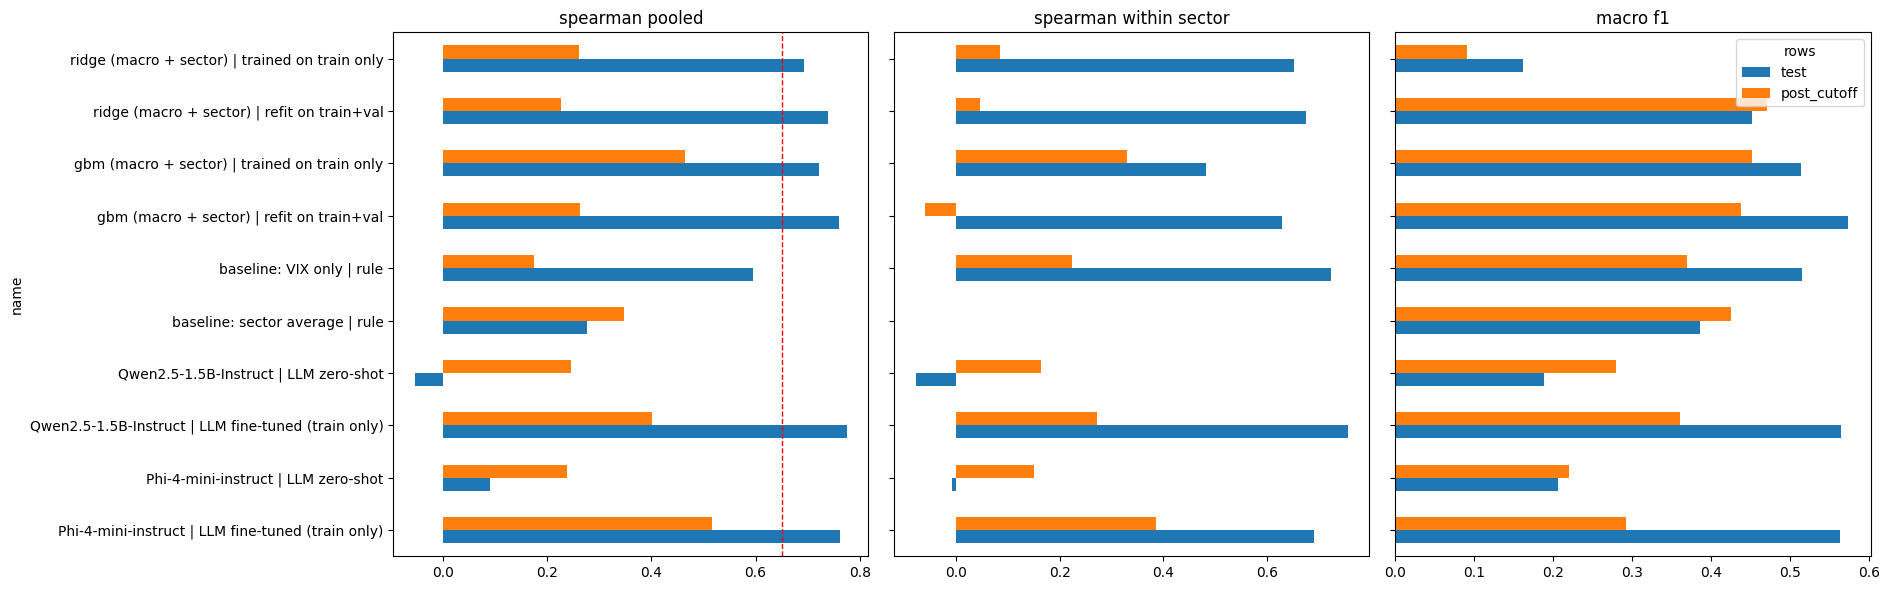

Ranking by average of pooled and within-sector Spearman (baselines excluded):

--- post_cutoff ---
                 model                     setting  avg_spearman  macro_f1
   Phi-4-mini-instruct LLM fine-tuned (train only)         0.452     0.293
  gbm (macro + sector)       trained on train only         0.397     0.452
 Qwen2.5-1.5B-Instruct LLM fine-tuned (train only)         0.336     0.361
 Qwen2.5-1.5B-Instruct               LLM zero-shot         0.204     0.280
   Phi-4-mini-instruct               LLM zero-shot         0.194     0.220
ridge (macro + sector)       trained on train only         0.173     0.090
ridge (macro + sector)          refit on train+val         0.137     0.471
  gbm (macro + sector)          refit on train+val         0.101     0.438

--- test+post_cutoff ---
                 model                     setting  avg_spearman  macro_f1
   Phi-4-mini-instruct LLM fine-tuned (train only)         0.626     0.491
 Qwen2.5-1.5B-Instruct LLM fine-tuned (train only)

In [ ]:
import matplotlib.pyplot as plt
plot_df = master_df[master_df["rows"].isin(["test", "post_cutoff"])].copy()
plot_df["name"] = plot_df["model"] + " | " + plot_df["setting"]
order = list(dict.fromkeys(plot_df["name"]))
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
for ax, metric in zip(axes, ["spearman_pooled", "spearman_within_sector", "macro_f1"]):
    pv = plot_df.set_index(["name", "rows"])[metric].unstack("rows").reindex(index=order, columns=["test", "post_cutoff"])
    pv.iloc[::-1].plot.barh(ax=ax, legend=(metric == "macro_f1"))
    ax.set_title(metric.replace("_", " "))
    if metric == "spearman_pooled":
        ax.axvline(0.65, color="red", ls="--", lw=1)
fig.tight_layout(); fig.savefig(OUT_DIR / "plot_master_comparison.png", dpi=160); plt.show()

print("Ranking by average of pooled and within-sector Spearman (baselines excluded):")
for gname in ["post_cutoff", "test+post_cutoff"]:
    t = master_df[(master_df["rows"] == gname) & ~master_df["model"].str.startswith("baseline")].copy()
    t["avg_spearman"] = t[["spearman_pooled", "spearman_within_sector"]].mean(axis=1)
    print(f"\n--- {gname} ---")
    print(t.sort_values("avg_spearman", ascending=False)[["model", "setting", "avg_spearman", "macro_f1"]].round(3).to_string(index=False))

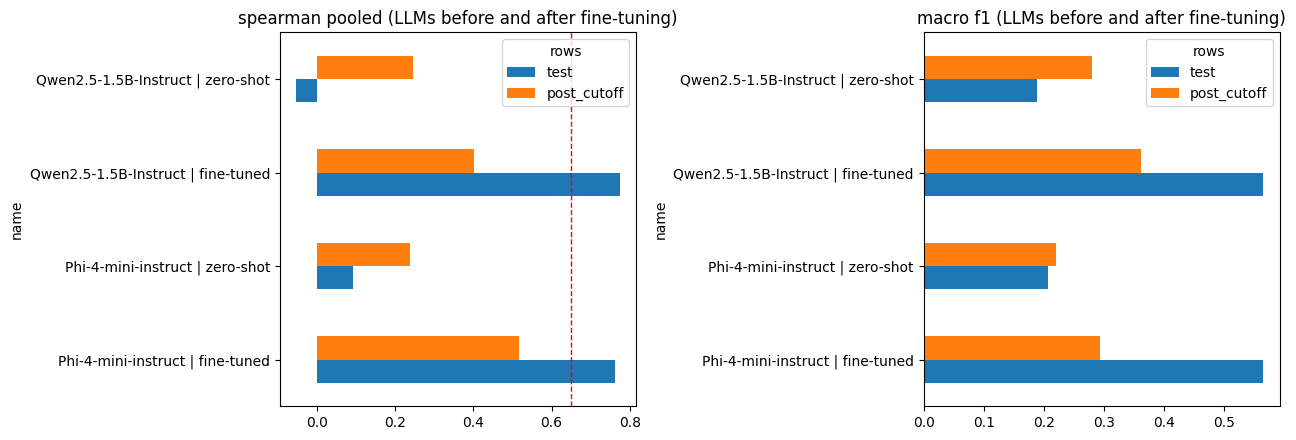

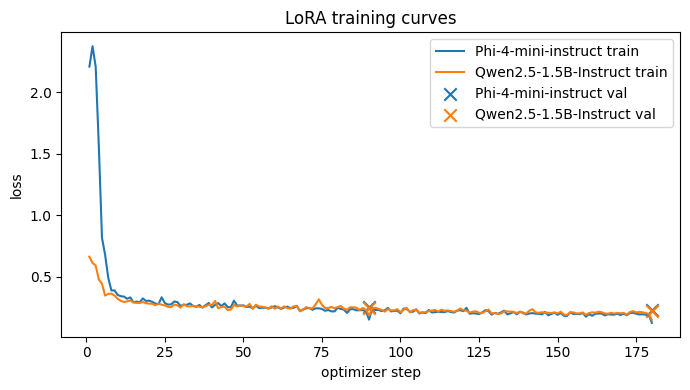

Spread of the volatility each LLM predicts (a model that always says ~15% has std near 0):
                                  count   mean   std   min   max  nunique
model                 setting                                            
Phi-4-mini-instruct   fine-tuned    594  16.26  5.71   8.6  32.8       46
                      zero-shot     594  15.16  0.43  15.0  16.5        4
Qwen2.5-1.5B-Instruct fine-tuned    594  15.11  4.04  10.0  34.9       58
                      zero-shot     594  15.61  0.39  15.0  18.5       17
Actual next-60-day volatility on the same rows: mean 19.0%, std 7.0%

Sample fine-tuned outputs:
  Qwen2.5-1.5B-Instruct    Materials              actual  22.9% (HIGH    ) -> {"expected_vol_pct": 24.1, "risk_label": "HIGH", "macro_risk_score": 8.1}
  Qwen2.5-1.5B-Instruct    Communication Services actual  31.0% (HIGH    ) -> {"expected_vol_pct": 19.0, "risk_label": "HIGH", "macro_risk_score": 6.9}
  Qwen2.5-1.5B-Instruct    Energy                 actual  30.6% 

In [ ]:
import matplotlib.pyplot as plt
if len(llm_metrics) and not SMOKE:
    t = llm_metrics[llm_metrics["rows"].isin(["test", "post_cutoff"])].copy()
    t["name"] = t["model"] + " | " + t["setting"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, metric in zip(axes, ["spearman_pooled", "macro_f1"]):
        t.set_index(["name", "rows"])[metric].unstack("rows").reindex(columns=["test", "post_cutoff"]).plot.barh(ax=ax)
        ax.set_title(metric.replace("_", " ") + " (LLMs before and after fine-tuning)")
        if metric == "spearman_pooled":
            ax.axvline(0.65, color="red", ls="--", lw=1)
    fig.tight_layout(); fig.savefig(OUT_DIR / "plot_llm_before_after.png", dpi=160); plt.show()

if train_log:
    lg = pd.DataFrame(train_log)
    fig, ax = plt.subplots(figsize=(7, 4))
    for m_, g in lg.dropna(subset=["train_loss"]).groupby("model"):
        ax.plot(g["step"], g["train_loss"], label=f"{m_} train")
    for m_, g in lg.dropna(subset=["val_loss"]).groupby("model"):
        ax.scatter(g["step"], g["val_loss"], marker="x", s=80, label=f"{m_} val")
    ax.set_xlabel("optimizer step"); ax.set_ylabel("loss"); ax.set_title("LoRA training curves"); ax.legend()
    fig.tight_layout(); fig.savefig(OUT_DIR / "plot_training_curves.png", dpi=160); plt.show()

if len(llm_preds):
    p = llm_preds[llm_preds["valid"]]
    print("Spread of the volatility each LLM predicts (a model that always says ~15% has std near 0):")
    print(p.groupby(["model", "setting"])["exp_vol_pct"].agg(["count", "mean", "std", "min", "max", "nunique"]).round(2).to_string())
    print("Actual next-60-day volatility on the same rows: mean %.1f%%, std %.1f%%" % (llm_preds["fwd_vol_60d"].mean() * 100, llm_preds["fwd_vol_60d"].std() * 100))
    print("\nSample fine-tuned outputs:")
    for _, r in llm_preds[llm_preds["setting"] == "fine-tuned"].head(4).iterrows():
        print(f"  {r['model']:24s} {r['sector']:22s} actual {r['fwd_vol_60d'] * 100:5.1f}% ({r['risk_label']:8s}) -> {r['raw_output'][:100]}")

## 9. Save

In [ ]:
import joblib, shutil
bundle = {"model": final_models[AGENT_KEY], "features": FEATURE_SETS[AGENT_KEY[0]], "key": AGENT_KEY,
          "params": best[AGENT_KEY]["params"], "thresholds": thr, "target": "log(fwd_vol_60d)",
          "trained_on": "train + val (2006-2021)"}
joblib.dump(bundle, OUT_DIR / "macro_agent_model.joblib")
json.dump({"classical_agent_model": list(AGENT_KEY), "params": best[AGENT_KEY]["params"],
           "results": results.to_dict(orient="records")},
          open(OUT_DIR / "metrics.json", "w"), indent=2, default=str)
print("saved in", OUT_DIR)
print(sorted(p.name for p in OUT_DIR.iterdir()))
if SMOKE and RUN_LLM_FINETUNING:
    print("SMOKE run finished without errors. Set SMOKE = False in section 1 and run all again for real results.")
else:
    archive = shutil.make_archive("/content/macro_all_results", "zip", OUT_DIR)
    if IN_COLAB:
        files.download(archive)
    else:
        print("archive:", archive)

saved in /content/drive/MyDrive/macro_agent_results
['adapter_Phi-4-mini-instruct', 'adapter_Qwen2.5-1.5B-Instruct', 'feature_importance_top15.csv', 'finetune_metrics.csv', 'finetune_predictions.csv', 'macro_agent_model.joblib', 'master_comparison.csv', 'metrics.json', 'plot_confusion_matrix_test.png', 'plot_feature_importance.png', 'plot_llm_before_after.png', 'plot_master_comparison.png', 'plot_pred_vs_actual.png', 'plot_spearman_by_model.png', 'plot_training_curves.png', 'results_by_split.csv', 'same_rows_as_llm_comparison.csv', 'test_predictions.csv', 'train_log.csv', 'tuning_results.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Using the adapters later (not executed)
The adapters in Drive are small LoRA files. To reuse one, load the original model and apply the adapter:
```python
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
adapter_dir = "/content/drive/MyDrive/macro_finetune_outputs/adapter_Qwen2.5-1.5B-Instruct"
tok = AutoTokenizer.from_pretrained(adapter_dir)
base = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", torch_dtype=torch.bfloat16).to("cuda")
model = PeftModel.from_pretrained(base, adapter_dir)
```
Build the prompt exactly as in section 4 (no dates) and generate with the chat template, as `generate()` does above.